# Inequality Constrained Optimization

Using the barrier method to handle inequality constraints with GMM.

Includes both an abstract example and a physically motivated reaction equilibrium problem.

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings

# Configure JAX to use CPU (avoids GPU/XLA compatibility issues)
import os
os.environ['JAX_PLATFORMS'] = 'cpu'

# Import reusable utilities from local module
from generative_optimization import (
    generate_samples,
    estimate_sample_size,
    best_gmm,
    best_gmm_bic,
    cluster_stats,
    validate_gmm
)

# Figure settings
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['figure.dpi'] = 150

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore', category=RuntimeWarning)

<a id='inequality'></a>
### 4.2 Inequality Constraints (Barrier Method)

For inequality constraints, we use the barrier method.

**Problem:** Minimize $(x-2)^2 + (y-1)^2$ subject to $x + y \geq 1$

In [35]:
# Scipy solution
from scipy.optimize import minimize

def f(X):
    x, y = X
    return (x - 2)**2 + (y - 1)**2

def c1(X):
    x, y = X
    return x + y - 1  # >= 0

sol = minimize(f, [1, 1], constraints={'type': 'ineq', 'fun': c1})

print("Scipy solution:")
print(f"  x = {sol.x}")
print(f"  f(x) = {sol.fun}")

Scipy solution:
  x = [2.         0.99999999]
  f(x) = 5.551115123125783e-17


In [36]:
# Barrier method with JAX
import jax.numpy as jnp
from jax import jacobian, vmap

def barrier_objective(X, mu=1e-7):
    x, y = X
    obj = (x - 2)**2 + (y - 1)**2
    barrier = -mu * jnp.log(x + y - 1)
    return obj + barrier

# Generate samples in feasible region (x + y > 1)
bounds = [[0, 3], [0, 3]]
inputs = generate_samples(bounds, n_samples=512, method='uniform', seed=42)

# Filter to feasible points
feasible = inputs[:, 0] + inputs[:, 1] > 1.01  # small margin for log
inputs = inputs[feasible]

print(f"Feasible samples: {len(inputs)}")

Feasible samples: 469


In [37]:
# Compute gradients
outputs = vmap(jacobian(barrier_objective))(inputs)
data = np.hstack([inputs, outputs])

print(f"Data shape: {data.shape}")
print("Columns: [x, y, ∂f_barrier/∂x, ∂f_barrier/∂y]")

Data shape: (469, 4)
Columns: [x, y, ∂f_barrier/∂x, ∂f_barrier/∂y]


Best model: 2 components


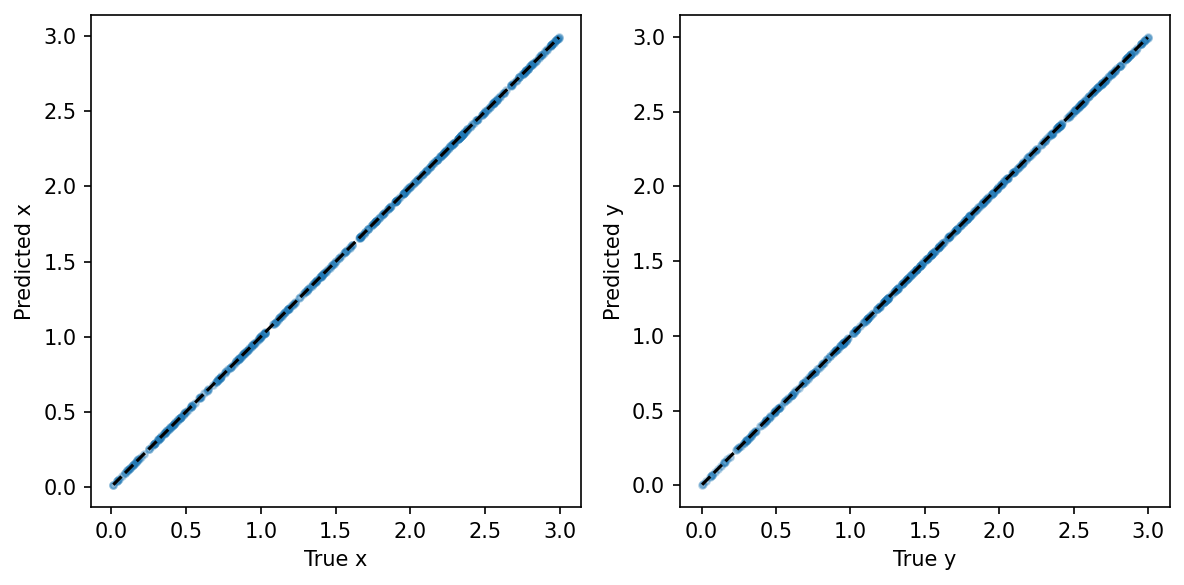

In [38]:
# Build and validate GMM
gmm, info = best_gmm(data, verbose=False)
print(f"Best model: {info['best_k']} components")

# Validate
pred = gmm.predict([2, 3], data[:, 2:])

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for i, (ax, label) in enumerate(zip(axes, ['x', 'y'])):
    ax.scatter(data[:, i], pred[:, i], alpha=0.3, s=10)
    lims = [data[:, i].min(), data[:, i].max()]
    ax.plot(lims, lims, 'k--')
    ax.set_xlabel(f'True {label}')
    ax.set_ylabel(f'Predicted {label}')

plt.tight_layout()
plt.show()

In [39]:
# Solve: condition on gradient = 0
P = gmm.predict([2, 3], np.array([[0.0, 0.0]]))

print("Generative solution:")
print(f"  x = {P[0, 0]:.6f}")
print(f"  y = {P[0, 1]:.6f}")
print(f"\nExpected: x = 2.0, y = 1.0")

Generative solution:
  x = 2.000000
  y = 1.000000

Expected: x = 2.0, y = 1.0


### 4.3 Reaction Equilibrium with Concentration Constraints

A physically motivated example: finding the equilibrium composition of a reversible reaction $A + B \rightleftharpoons 2C$ in a batch reactor.

Given initial concentrations $C_{A0} = C_{B0} = 1$ mol/L and $C_{C0} = 0$, the concentrations evolve with extent of reaction $\xi$:
- $C_A = 1 - \xi$
- $C_B = 1 - \xi$
- $C_C = 2\xi$

The equilibrium condition:
$$K_{eq} = \frac{C_C^2}{C_A \cdot C_B} = \frac{(2\xi)^2}{(1-\xi)^2}$$

**Root finding formulation:** Find $\xi$ where $f(\xi) = K_{eq}(1-\xi)^2 - 4\xi^2 = 0$

**Physical constraints:** Non-negative concentrations require $0 < \xi < 1$

**GMM approach:** We sample $\xi$ only in the feasible region $(0, 1)$, train a GMM on $[\xi, f(\xi)]$, and condition on $f(\xi) = 0$ to find the root. The constraint is enforced by the sampling domain.

In [40]:
# Reaction equilibrium: A + B ⇌ 2C
# Parameters
Keq = 4.0  # Equilibrium constant
mu = 1e-6  # Barrier parameter

# Analytical solution
# Keq(1-ξ)² = 4ξ² → for Keq=4: (1-ξ)² = ξ² → 1-ξ = ±ξ
# Physical root: ξ = 0.5
xi_analytical = 0.5

print("Reaction Equilibrium: A + B ⇌ 2C")
print(f"Keq = {Keq}")
print(f"Barrier parameter μ = {mu}")
print(f"\nAnalytical solution: ξ = {xi_analytical}")
print(f"Equilibrium concentrations:")
print(f"  CA = CB = {1 - xi_analytical:.2f} mol/L")
print(f"  CC = {2 * xi_analytical:.2f} mol/L")

# Verify with scipy
from scipy.optimize import minimize_scalar

def residual_eq(xi):
    return Keq * (1 - xi)**2 - 4 * xi**2

result_scipy_eq = minimize_scalar(lambda x: residual_eq(x)**2, bounds=(0.01, 0.99), method='bounded')
print(f"\nScipy verification: ξ = {result_scipy_eq.x:.6f}")

Reaction Equilibrium: A + B ⇌ 2C
Keq = 4.0
Barrier parameter μ = 1e-06

Analytical solution: ξ = 0.5
Equilibrium concentrations:
  CA = CB = 0.50 mol/L
  CC = 1.00 mol/L

Scipy verification: ξ = 0.500000


In [41]:
# For ROOT FINDING, we condition on the residual = 0, not the gradient = 0
# The barrier just ensures we sample in the feasible region

import jax
import jax.numpy as jnp

def residual_fn(xi):
    """Equilibrium residual - should equal zero at solution."""
    return Keq * (1 - xi)**2 - 4 * xi**2

# Generate training data: sample ξ in feasible region
n_eq_samples = 2000
np.random.seed(42)
xi_samples = np.random.uniform(0.01, 0.99, n_eq_samples)

# Compute residual for each sample
residuals = np.array([residual_fn(xi) for xi in xi_samples])

# Build joint dataset: [ξ, f(ξ)]
data_eq = np.column_stack([xi_samples, residuals])

print(f"Training data shape: {data_eq.shape}")
print(f"Columns: [ξ, f(ξ)]")
print(f"ξ range: [{xi_samples.min():.3f}, {xi_samples.max():.3f}]")
print(f"Residual range: [{residuals.min():.3f}, {residuals.max():.3f}]")

# Verify: residual should be zero at xi = 0.5
print(f"\nVerification: f(0.5) = {residual_fn(0.5):.6f} (should be 0)")

Training data shape: (2000, 2)
Columns: [ξ, f(ξ)]
ξ range: [0.013, 0.990]
Residual range: [-3.918, 3.895]

Verification: f(0.5) = 0.000000 (should be 0)


In [42]:
# Train GMM
gmm_eq, gmm_eq_info = best_gmm(data_eq, verbose=True)
print(f"\nBest GMM: {gmm_eq_info['best_k']} components")

k=1: BIC=-14895.7 *
k=2: BIC=-15183.3 *
k=3: BIC=-15280.2 *
k=4: BIC=-15320.8 *
k=5: BIC=-15310.4
k=6: BIC=-15296.7
k=7: BIC=-15270.6
k=8: BIC=-15242.9
k=9: BIC=-15214.5
k=10: BIC=-15183.1
k=11: BIC=-15149.7
k=12: BIC=-15118.7
k=13: BIC=-15065.7
k=14: BIC=-15045.9
Early stopping at k=14

Best GMM: 4 components


In [43]:
# GMM: Condition on residual = 0 (ROOT FINDING)
c_gmm_eq = gmm_eq.condition([1], [[0.0]])
xi_gmm_samples = c_gmm_eq.sample(1000)[:, 0]

print("GMM Solution (conditioning on f(ξ) = 0):")
print(f"  ξ = {xi_gmm_samples.mean():.4f} ± {xi_gmm_samples.std():.4f}")
print(f"  Analytical: ξ = {xi_analytical}")

# Verify equilibrium residual at GMM solution
residual_gmm_eq = residual_fn(xi_gmm_samples.mean())
print(f"  Residual at mean: {residual_gmm_eq:.6f}")

GMM Solution (conditioning on f(ξ) = 0):
  ξ = 0.5000 ± 0.0010
  Analytical: ξ = 0.5
  Residual at mean: -0.000019


In [44]:
# Summary comparison
print("Reaction Equilibrium Comparison: A + B ⇌ 2C")
print("=" * 60)
print(f"Equilibrium constant: Keq = {Keq}")
print()

print(f"{'Method':<20} {'ξ':<15} {'|Residual|':<15}")
print("-" * 50)

# Analytical
print(f"{'Analytical':<20} {xi_analytical:<15.6f} {abs(residual_fn(xi_analytical)):<15.6f}")

# Scipy
print(f"{'Scipy':<20} {result_scipy_eq.x:<15.6f} {abs(residual_fn(result_scipy_eq.x)):<15.6f}")

# GMM
xi_gmm_mean = xi_gmm_samples.mean()
print(f"{'GMM':<20} {xi_gmm_mean:<15.6f} {abs(residual_fn(xi_gmm_mean)):<15.6f}")

Reaction Equilibrium Comparison: A + B ⇌ 2C
Equilibrium constant: Keq = 4.0

Method               ξ               |Residual|     
--------------------------------------------------
Analytical           0.500000        0.000000       
Scipy                0.500000        0.000000       
GMM                  0.500002        0.000019       


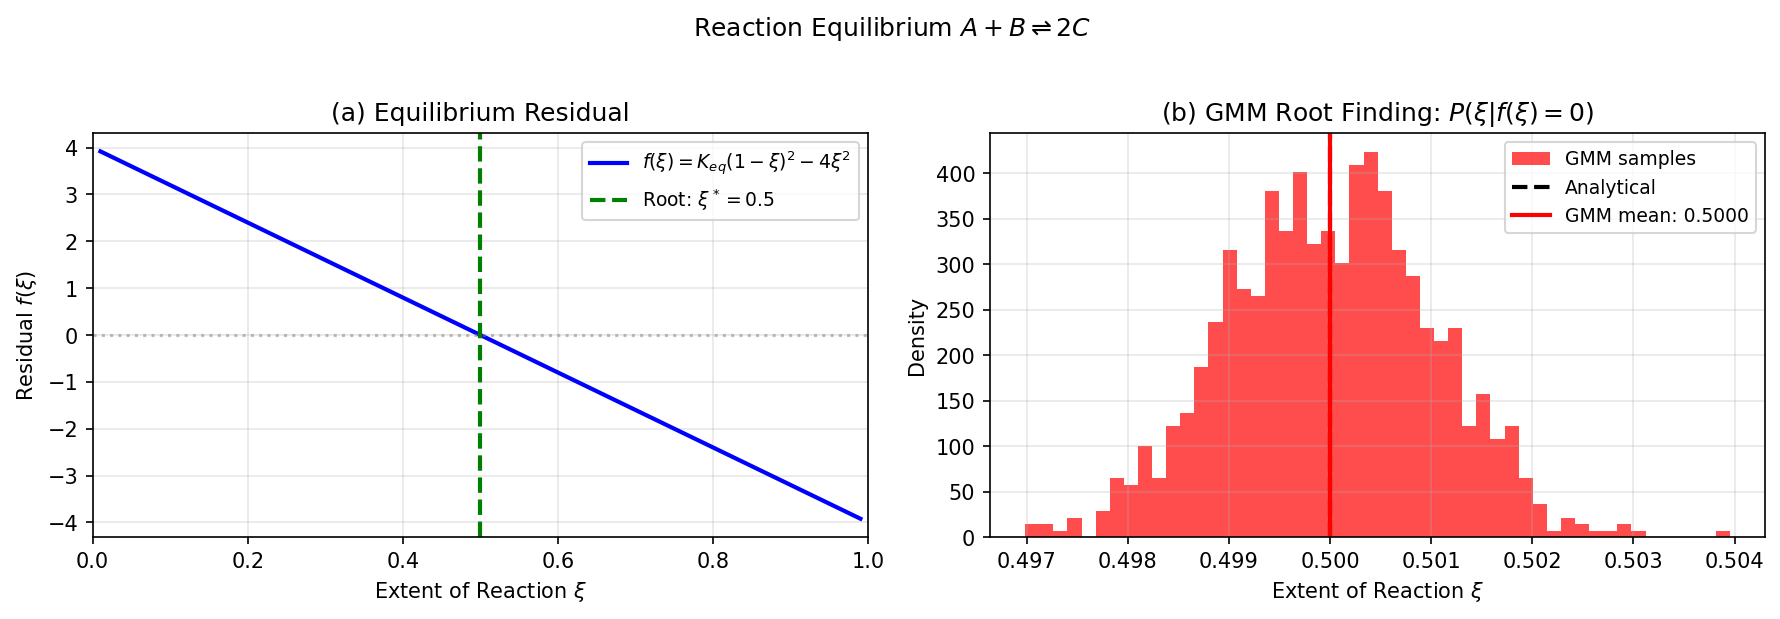

In [45]:
# Visualize results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left: Residual function
xi_plot = np.linspace(0.01, 0.99, 200)
f_plot = np.array([residual_fn(x) for x in xi_plot])

ax1.plot(xi_plot, f_plot, 'b-', lw=2, label='$f(\\xi) = K_{eq}(1-\\xi)^2 - 4\\xi^2$')
ax1.axhline(0, color='gray', ls=':', alpha=0.5)
ax1.axvline(xi_analytical, color='green', ls='--', lw=2, label=f'Root: $\\xi^*={xi_analytical}$')

ax1.set_xlabel('Extent of Reaction $\\xi$')
ax1.set_ylabel('Residual $f(\\xi)$')
ax1.set_title('(a) Equilibrium Residual')
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 1)

# Right: GMM histogram
ax2.hist(xi_gmm_samples, bins=50, alpha=0.7, color='red', 
         label='GMM samples', density=True)
ax2.axvline(xi_analytical, color='black', ls='--', lw=2, label='Analytical')
ax2.axvline(xi_gmm_samples.mean(), color='red', ls='-', lw=2, label=f'GMM mean: {xi_gmm_samples.mean():.4f}')

ax2.set_xlabel('Extent of Reaction $\\xi$')
ax2.set_ylabel('Density')
ax2.set_title('(b) GMM Root Finding: $P(\\xi | f(\\xi) = 0)$')
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle('Reaction Equilibrium $A + B \\rightleftharpoons 2C$', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()